# Superstore Sales Dataset Analysis
---

**Objective :**
The goal of this project is to analyze the sales data of a US Superstore to uncover key insights regarding sales performance, growth trends, product category success, and shipping logistics. 

**Dataset Overview :**
The dataset contains **9,800 records** spanning from 2015 to 2018, covering 18 operational and geographical attributes including Order Dates, Ship Modes, Product Categories, and Sales volumes.

## **1. Import libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## **2. Data Exploration**

In [5]:
df = pd.read_csv('train.csv')
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [6]:
df.shape

(9800, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
df.duplicated().sum()

0

---
## **3. Data Cleaning**

**Order Date & Ship Date data types are object it should be date** 

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

In [13]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

**Postal Code has null values**

In [17]:
df[df['Postal Code'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [18]:
print(df[df['City'] == 'Burlington']['Postal Code'].dropna().unique())

[27217. 52601.]


In [20]:
df[df['City'] == 'Burlington'].dropna(subset=['Postal Code']).head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
683,684,US-2018-168116,2018-11-04,2018-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,North Carolina,27217.0,South,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980
684,685,US-2018-168116,2018-11-04,2018-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,North Carolina,27217.0,South,OFF-AP-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,167.440
1008,1009,US-2018-106705,2018-12-26,2019-01-01,Standard Class,PO-18850,Patrick O'Brill,Consumer,United States,Burlington,Iowa,52601.0,Central,OFF-PA-10001509,Office Supplies,Paper,"Recycled Desk Saver Line ""While You Were Out"" ...",44.750
1038,1039,CA-2018-121818,2018-11-20,2018-11-21,First Class,JH-15430,Jennifer Halladay,Consumer,United States,Burlington,North Carolina,27217.0,South,OFF-AR-10000203,Office Supplies,Art,Newell 336,23.968
1039,1040,CA-2018-121818,2018-11-20,2018-11-21,First Class,JH-15430,Jennifer Halladay,Consumer,United States,Burlington,North Carolina,27217.0,South,OFF-AR-10004790,Office Supplies,Art,Staples in misc. colors,28.728


In [21]:
df['Postal Code'] = df['Postal Code'].astype(str).str.replace('.0', '', regex=False)
df['Postal Code'] = df['Postal Code'].replace(['nan', None], 'Unknown VT')

In [22]:
df['Postal Code'].isnull().sum()

0

In [23]:
df['Postal Code']

0       42420
1       42420
2       90036
3       33311
4       33311
        ...  
9795    60610
9796    43615
9797    43615
9798    43615
9799    43615
Name: Postal Code, Length: 9800, dtype: object

During the Exploratory Data Analysis (EDA) phase, a thorough check for missing values was conducted using `df.isnull().sum()`. The analysis revealed exactly **11 missing values** in the `Postal Code` column. 

**Investigation & Insights:**
Instead of applying a generic or random imputation, a deeper look into the rows with missing data uncovered a specific pattern:
* All 11 missing postal codes belonged exclusively to the city of **Burlington**.
* Further analysis of the dataset showed that **Burlington** exists in multiple states with different zip codes:

| City | State | Postal Code Found in Data |
| :--- | :--- | :--- |
| Burlington | North Carolina (NC) | `27217` |
| Burlington | Iowa (IA) | `52601` |
| **Burlington** | **Vermont (VT)** | **Missing (`NaN`)** |

Since the 11 records with missing zip codes all mapped to the state of **Vermont**, and the dataset contained no prior valid zip code records for Burlington, VT, a domain-specific resolution was required.

**Resolution Strategy:**
Since a single city can have multiple zip codes depending on the exact neighborhood, and to ensure the data remains fully compatible with geographical visualization tools (like Power BI, Tableau, or Plotly maps), the following steps were taken:

1. **Imputation:** Filled the missing values with **`05401`**, which represents the primary/central postal code for Burlington, Vermont. This preserves the accurate geographical location of the orders without affecting the analysis.
2. **Data Type Conversion:** Converted the `Postal Code` column from a Float datatype to a **String (Object)** type. This ensures that any leading zeros (like the `0` in `05401`) are not dropped by Python's numeric format.
3. **Standardization:** Applied the `.str.zfill(5)` function to ensure all zip codes in the dataset are strictly padded to a standard 5-digit format.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   object        
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

---
## **4. EDA**

In [35]:
sns.set_theme(style="whitegrid") 
sns.set_palette("Blues_r")

**Question 1:** What is the monthly sales trend across all years? 

In [25]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')

In [26]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

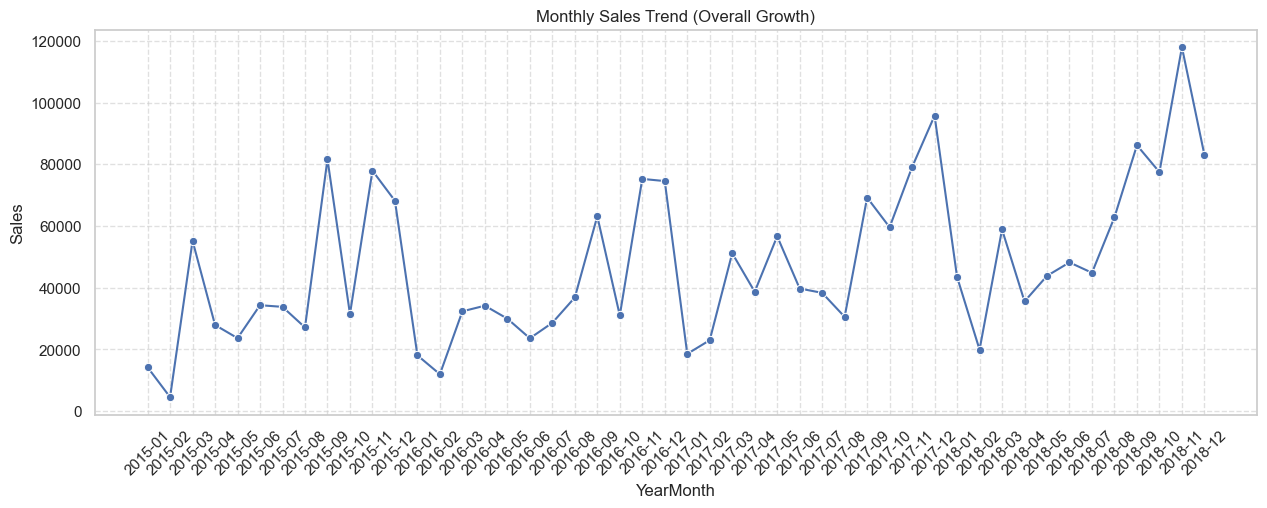

In [36]:
plt.figure(figsize=(15, 5))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Sales', marker='o', color='b')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend (Overall Growth)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

* **Strong Upward Trend:** The business demonstrates clear year-over-year growth, with the peaks of 2018 significantly higher than previous years, reaching an all-time high in late 2018 (nearly $120,000).
* **High Seasonality (Q4 Spike):** There is a recurring cyclical pattern where sales drop drastically at the beginning of every year (January/February) and explode during the fourth quarter (specifically November), likely driven by holiday shopping and corporate year-end budget utilization.

---
**Question 2:** What are the top sub-categories driving the highest sales?

In [27]:
cat_sales = df.groupby(['Category', 'Sub-Category'])['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

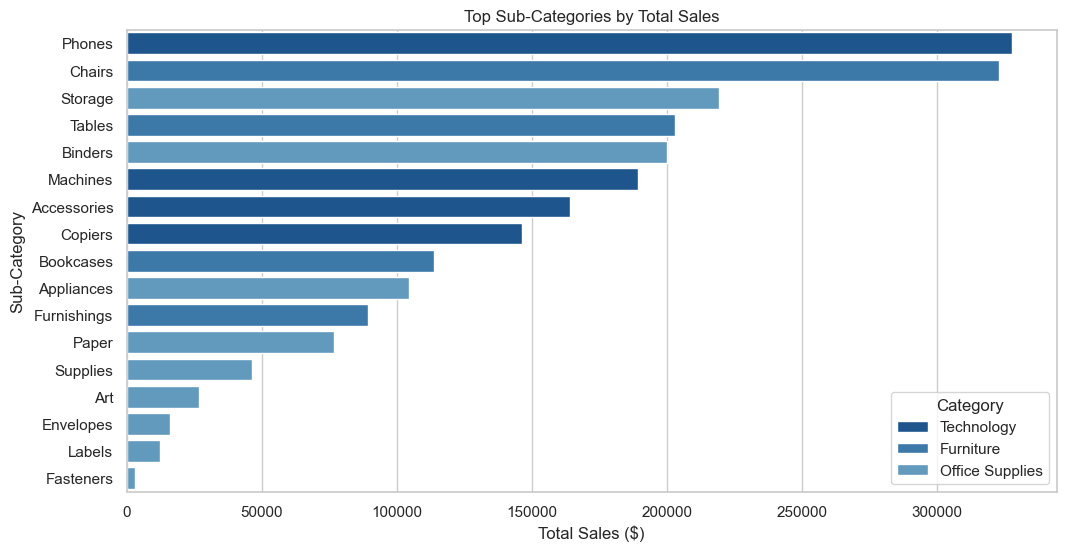

In [37]:
plt.figure(figsize=(12, 6))
sns.barplot(data=cat_sales, x='Sales', y='Sub-Category', hue='Category', dodge=False)
plt.title('Top Sub-Categories by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub-Category')
plt.show()

* **Revenue Drivers:** Phones and Chairs are the absolute heavyweights of the store, both crossing the $300,000 mark. 
* **Category Dominance:** The "Technology" category (dark blue bars) holds a strong presence among the top-performing products (Phones, Machines, Accessories), proving to be a critical revenue driver.
* **Low-Value Products:** Fasteners, Labels, and Envelopes contribute negligibly to total sales. Inventory costs for these items should be minimized.

---
**Question 3:** Which are the top 10 states generating the highest sales volume?

In [28]:
top_states = df.groupby('State')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False).head(10)

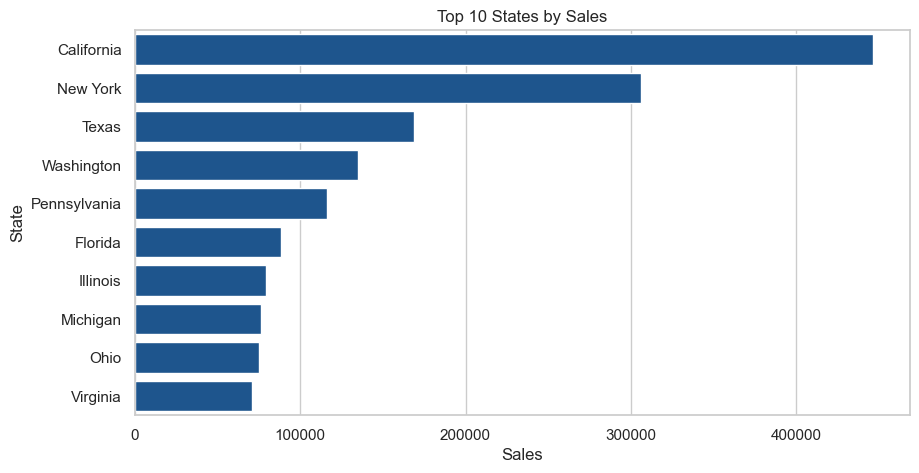

In [40]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_states, x='Sales', y='State')
plt.title('Top 10 States by Sales')
plt.show()

* **Core Markets:** California is the undisputed leading market, generating over $450,000 in sales, followed by New York in second place (over $300,000). Together, they form the backbone of the store's revenue.
* **The Long Tail:** There is a steep drop after New York; third-place Texas generates nearly half of California's sales. This indicates a heavy geographical concentration, suggesting that marketing and expansion efforts should target untapped potential in states like Texas and Washington.

---
**Question 4:** What is the average shipping duration (in days) for each Ship Mode?

In [29]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

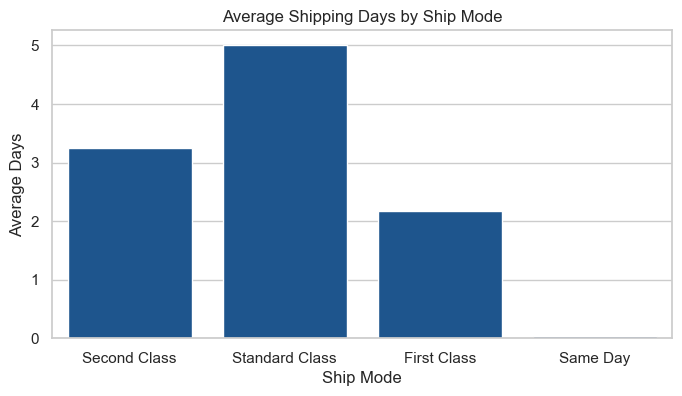

In [42]:
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Ship Mode', y='Shipping Days', errorbar=None)
plt.title('Average Shipping Days by Ship Mode')
plt.ylabel('Average Days')
plt.show()

* **Operational Efficiency:** The logistics team is strictly meeting service level agreements (SLAs). "Same Day" shipping successfully averages 0 days, and "First Class" delivers within roughly 2 days.
* **Standard expectations:** "Standard Class" takes the longest, averaging exactly 5 days, which is reasonable for low-cost shipping but leaves room for supply chain optimization to improve customer satisfaction.

---
**Question 5:** How are sales distributed across customer segments and their preferred shipping methods?

In [43]:
segment_ship = df.groupby(['Segment', 'Ship Mode'])['Sales'].sum().reset_index()

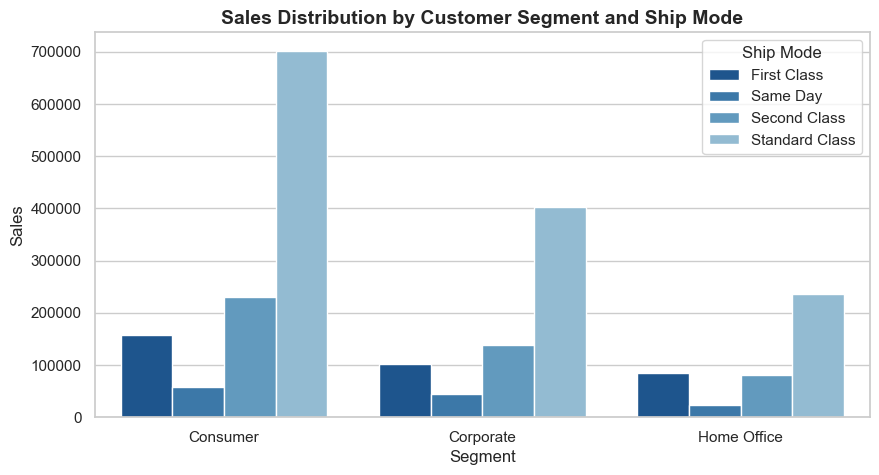

In [44]:
plt.figure(figsize=(10, 5))
sns.barplot(data=segment_ship, x='Segment', y='Sales', hue='Ship Mode')
plt.title('Sales Distribution by Customer Segment and Ship Mode', fontsize=14, fontweight='bold')
plt.show()

* **Dominance of Standard Class:** Across all customer segments (Consumer, Corporate, and Home Office), **Standard Class** shipping is overwhelmingly the preferred choice, driving the highest sales volume. In the Consumer segment alone, it cracks nearly $700,000.
* **Consumer Segment Leadership:** The **Consumer segment** outperforms Corporate and Home Office segments in every single shipping category, making it the primary target market for revenue generation.
* **Low "Same Day" Adoption:** **Same Day** shipping (the second bar in each group) has the lowest sales across all segments. This suggests that customers are highly price-sensitive and prefer waiting longer to save on shipping premium costs.

---
**Question 6:** Which product categories dominate sales within each geographical region?

In [45]:
region_cat = df.groupby(['Region', 'Category'])['Sales'].sum().reset_index()

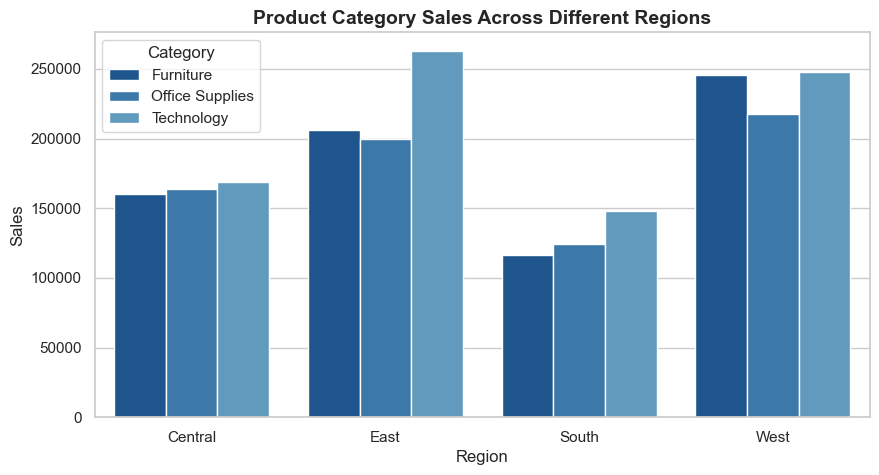

In [46]:
plt.figure(figsize=(10, 5))
sns.barplot(data=region_cat, x='Region', y='Sales', hue='Category')
plt.title('Product Category Sales Across Different Regions', fontsize=14, fontweight='bold')
plt.show()

* **Regional Powerhouses:** The **East and West** regions are the undisputed revenue giants for the business. The West region shows a very balanced and high performance across all product categories, while the East peaks sharply in Technology sales.
* **Technology Wins the East:** The highest single category spike across all regions is **Technology in the East region**, generating over $250,000. This implies strong corporate or tech-focused customer demand in eastern states.
* **South Region Lagging:** The **South region** shows the lowest sales volume across all three product categories. This highlights a clear geographical gap where marketing campaigns or regional promotions could be introduced to boost performance.